***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: indianred;">[1] Introdução</span>

***

### [1.1] Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from dados import Dados
from heuristicas import heuristica_maior_tempo_restante
from algoritmos import BFS, DFS, CustoUniforme, AEstrela
from stats import print_caminho, plot_metricas

### [1.2] Dados do Problema

In [2]:
dados = Dados({'A': 1, 'B': 2, 'C': 5, 'D': 10})
print(dados)

Dados do Problema:
  Pessoas: A, B, C, D
  Tempos: {'A': 1, 'B': 2, 'C': 5, 'D': 10}
  Estado Inicial: {A, B, C, D} inicio
  Estado Final: {} final



***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: royalblue;">[2] Execução dos Algoritmos</span>

***

### [2.1] Definição

In [3]:
bfs = BFS(dados)
dfs = DFS(dados)
uc = CustoUniforme(dados)
a_estrela = AEstrela(dados, heuristica_maior_tempo_restante)

algoritmos = [bfs, dfs, uc, a_estrela]

### [2.2] Execução


🧩 BFS
0: Estado inicial: {A, B, C, D} inicio
1: {'D', 'B'} levam a tocha para o final (custo: 10)
2: {'D'} levam a tocha para o início (custo: 10)
3: {'D', 'C'} levam a tocha para o final (custo: 10)
4: {'D'} levam a tocha para o início (custo: 10)
5: {'D', 'A'} levam a tocha para o final (custo: 10)
Estado final: {} final

📊 Custo total: 50
⏱️ Tempo de execução: 0.000456s
🌐 Nós expandidos: 20
📍 Visitados: 25


🧩 DFS
0: Estado inicial: {A, B, C, D} inicio
1: {'C', 'A'} levam a tocha para o final (custo: 5)
2: {'A'} levam a tocha para o início (custo: 1)
3: {'B', 'A'} levam a tocha para o final (custo: 2)
4: {'C', 'A'} levam a tocha para o início (custo: 5)
5: {'D', 'A'} levam a tocha para o final (custo: 10)
6: {'B', 'A'} levam a tocha para o início (custo: 2)
7: {'C', 'A'} levam a tocha para o final (custo: 5)
8: {'A'} levam a tocha para o início (custo: 1)
9: {'B', 'A'} levam a tocha para o final (custo: 2)
Estado final: {} final

📊 Custo total: 33
⏱️ Tempo de execução: 0.000184s
🌐 

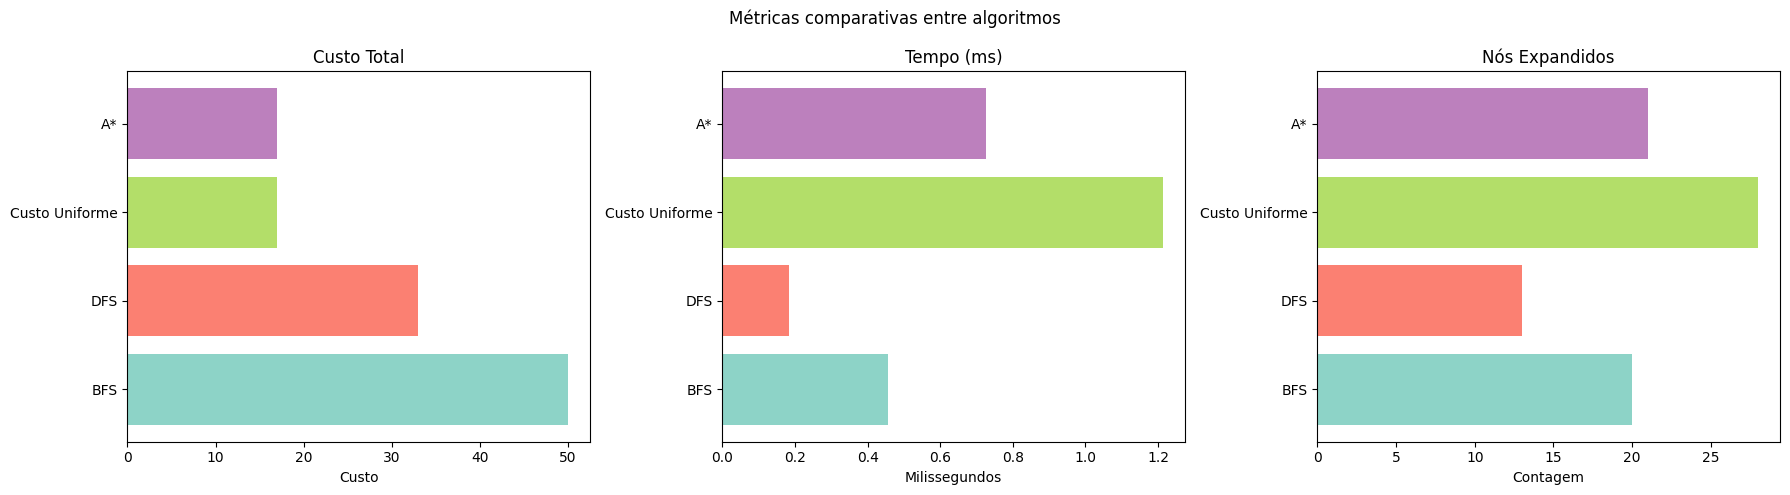

In [4]:
for alg in algoritmos:
    tempos = []
    for _ in range(100):
        alg.solve()
        tempos.append(alg.tempo_exec * 1000)
    
    alg.tempo_exec = np.mean(tempos) / 1000
    print_caminho(alg)

plot_metricas(algoritmos, 'Set3')


### [2.3] Visualização dos Resultados

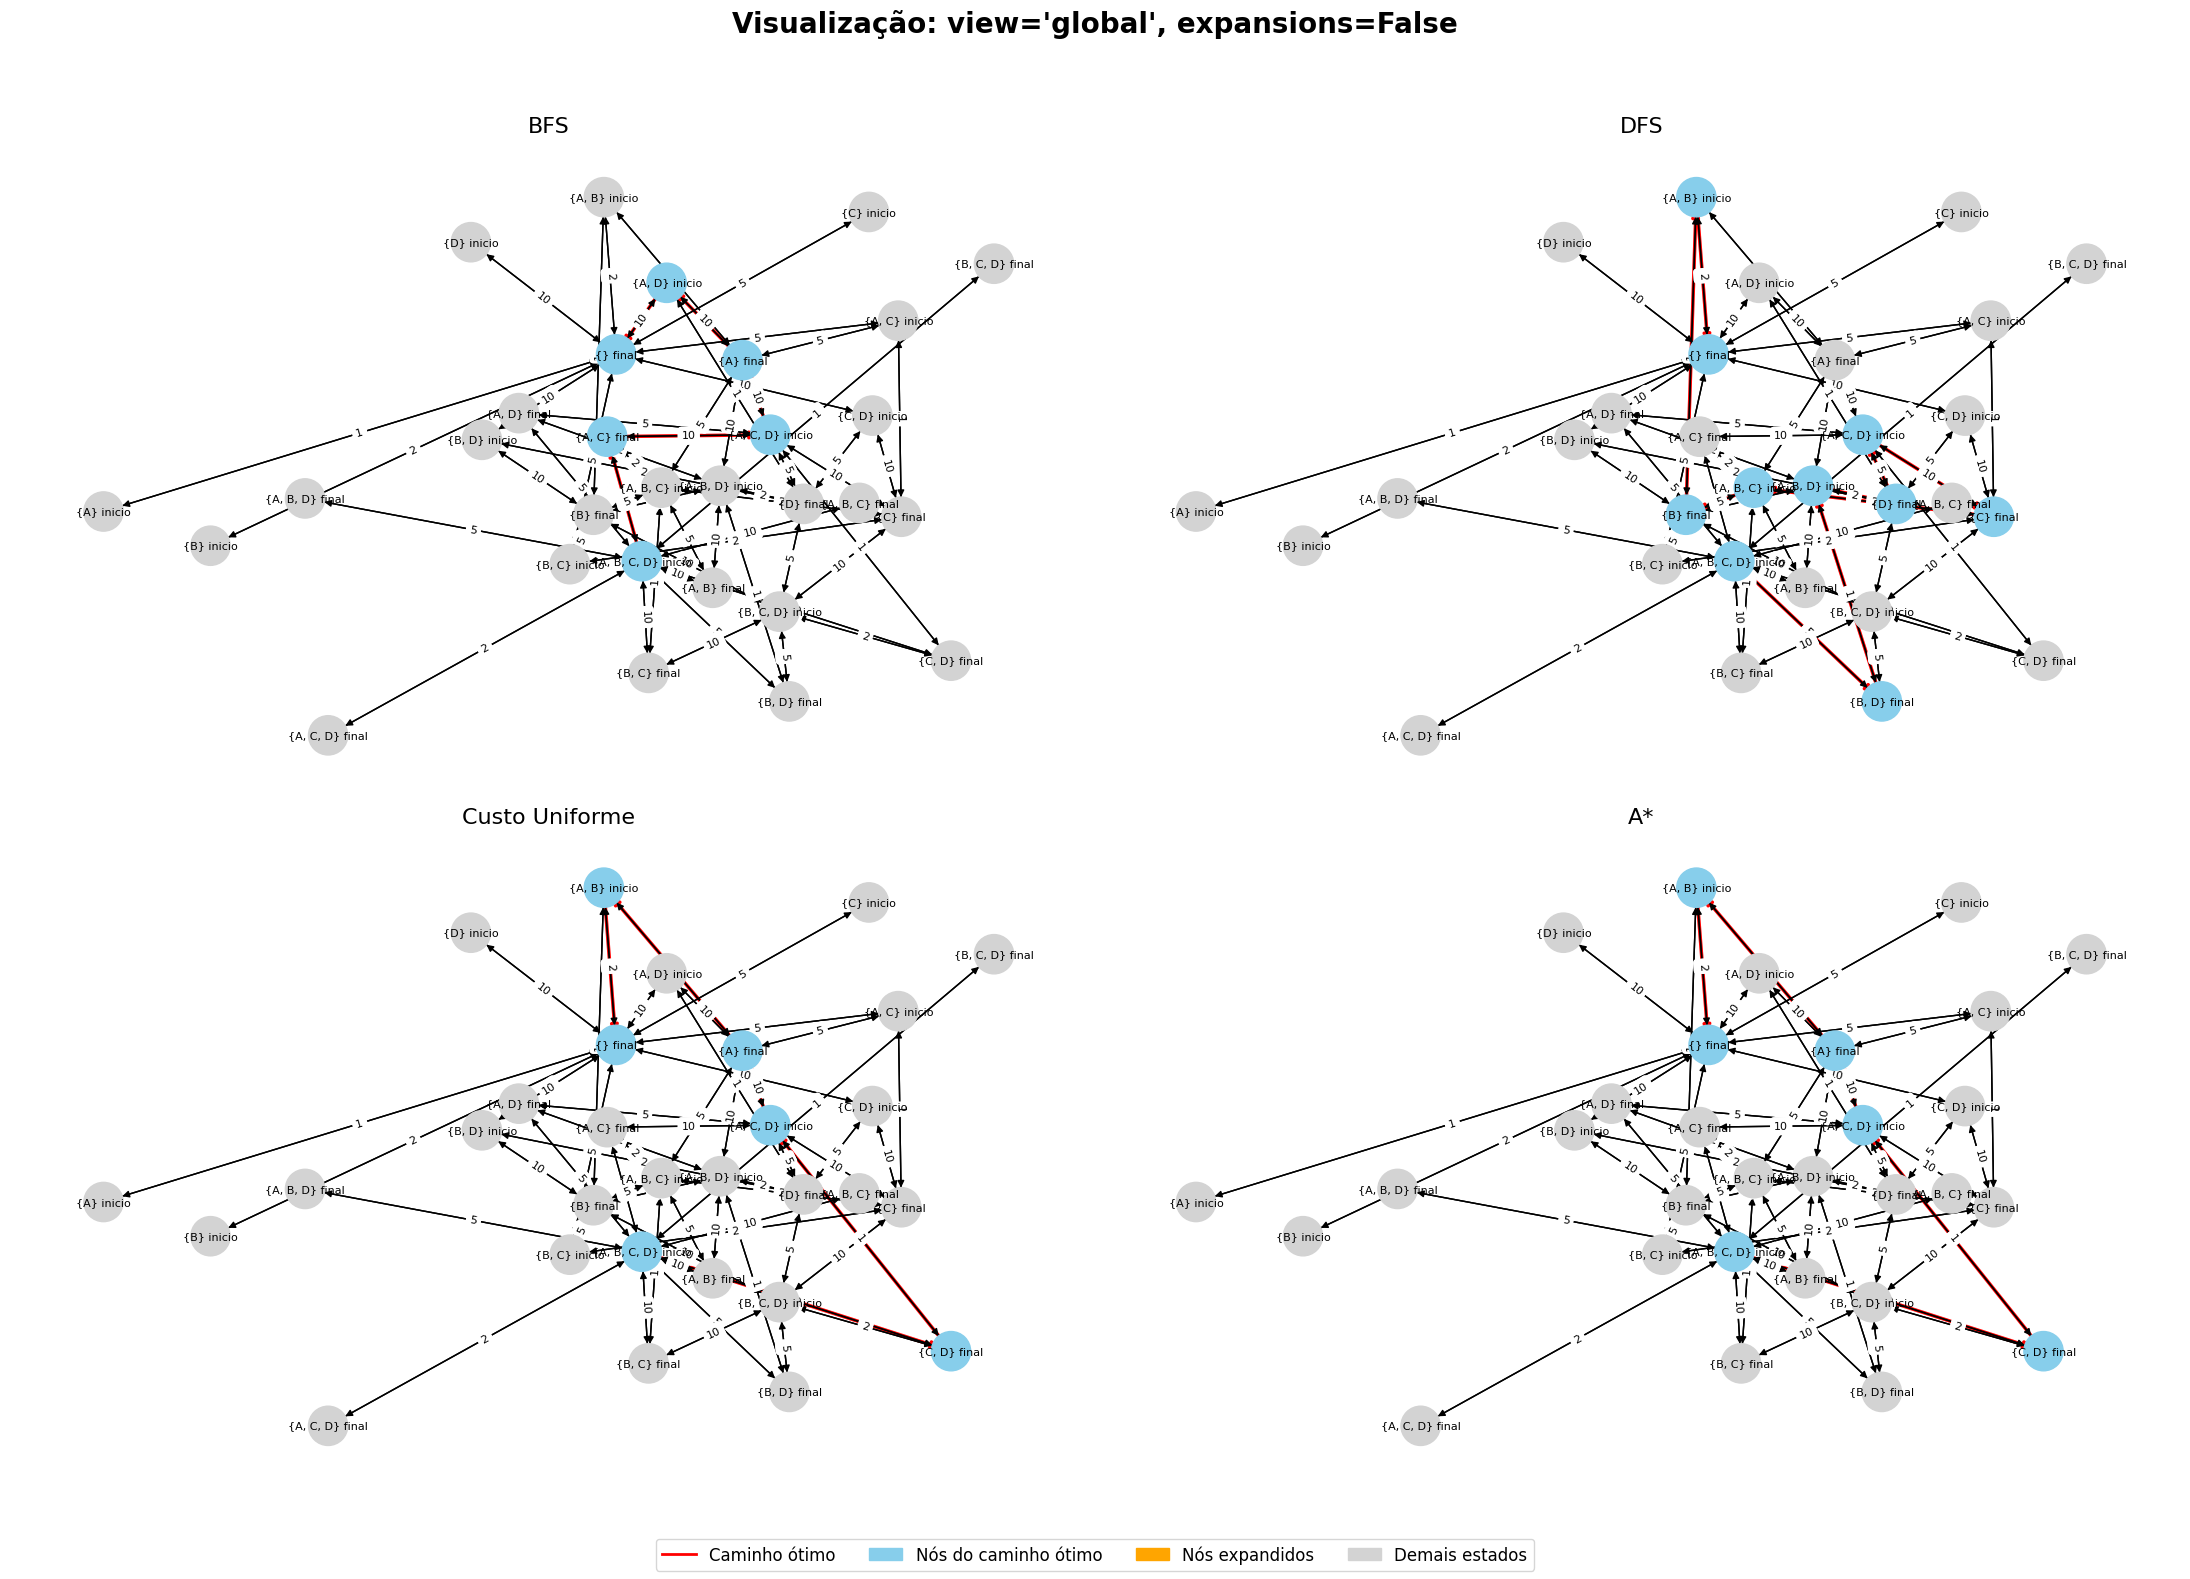

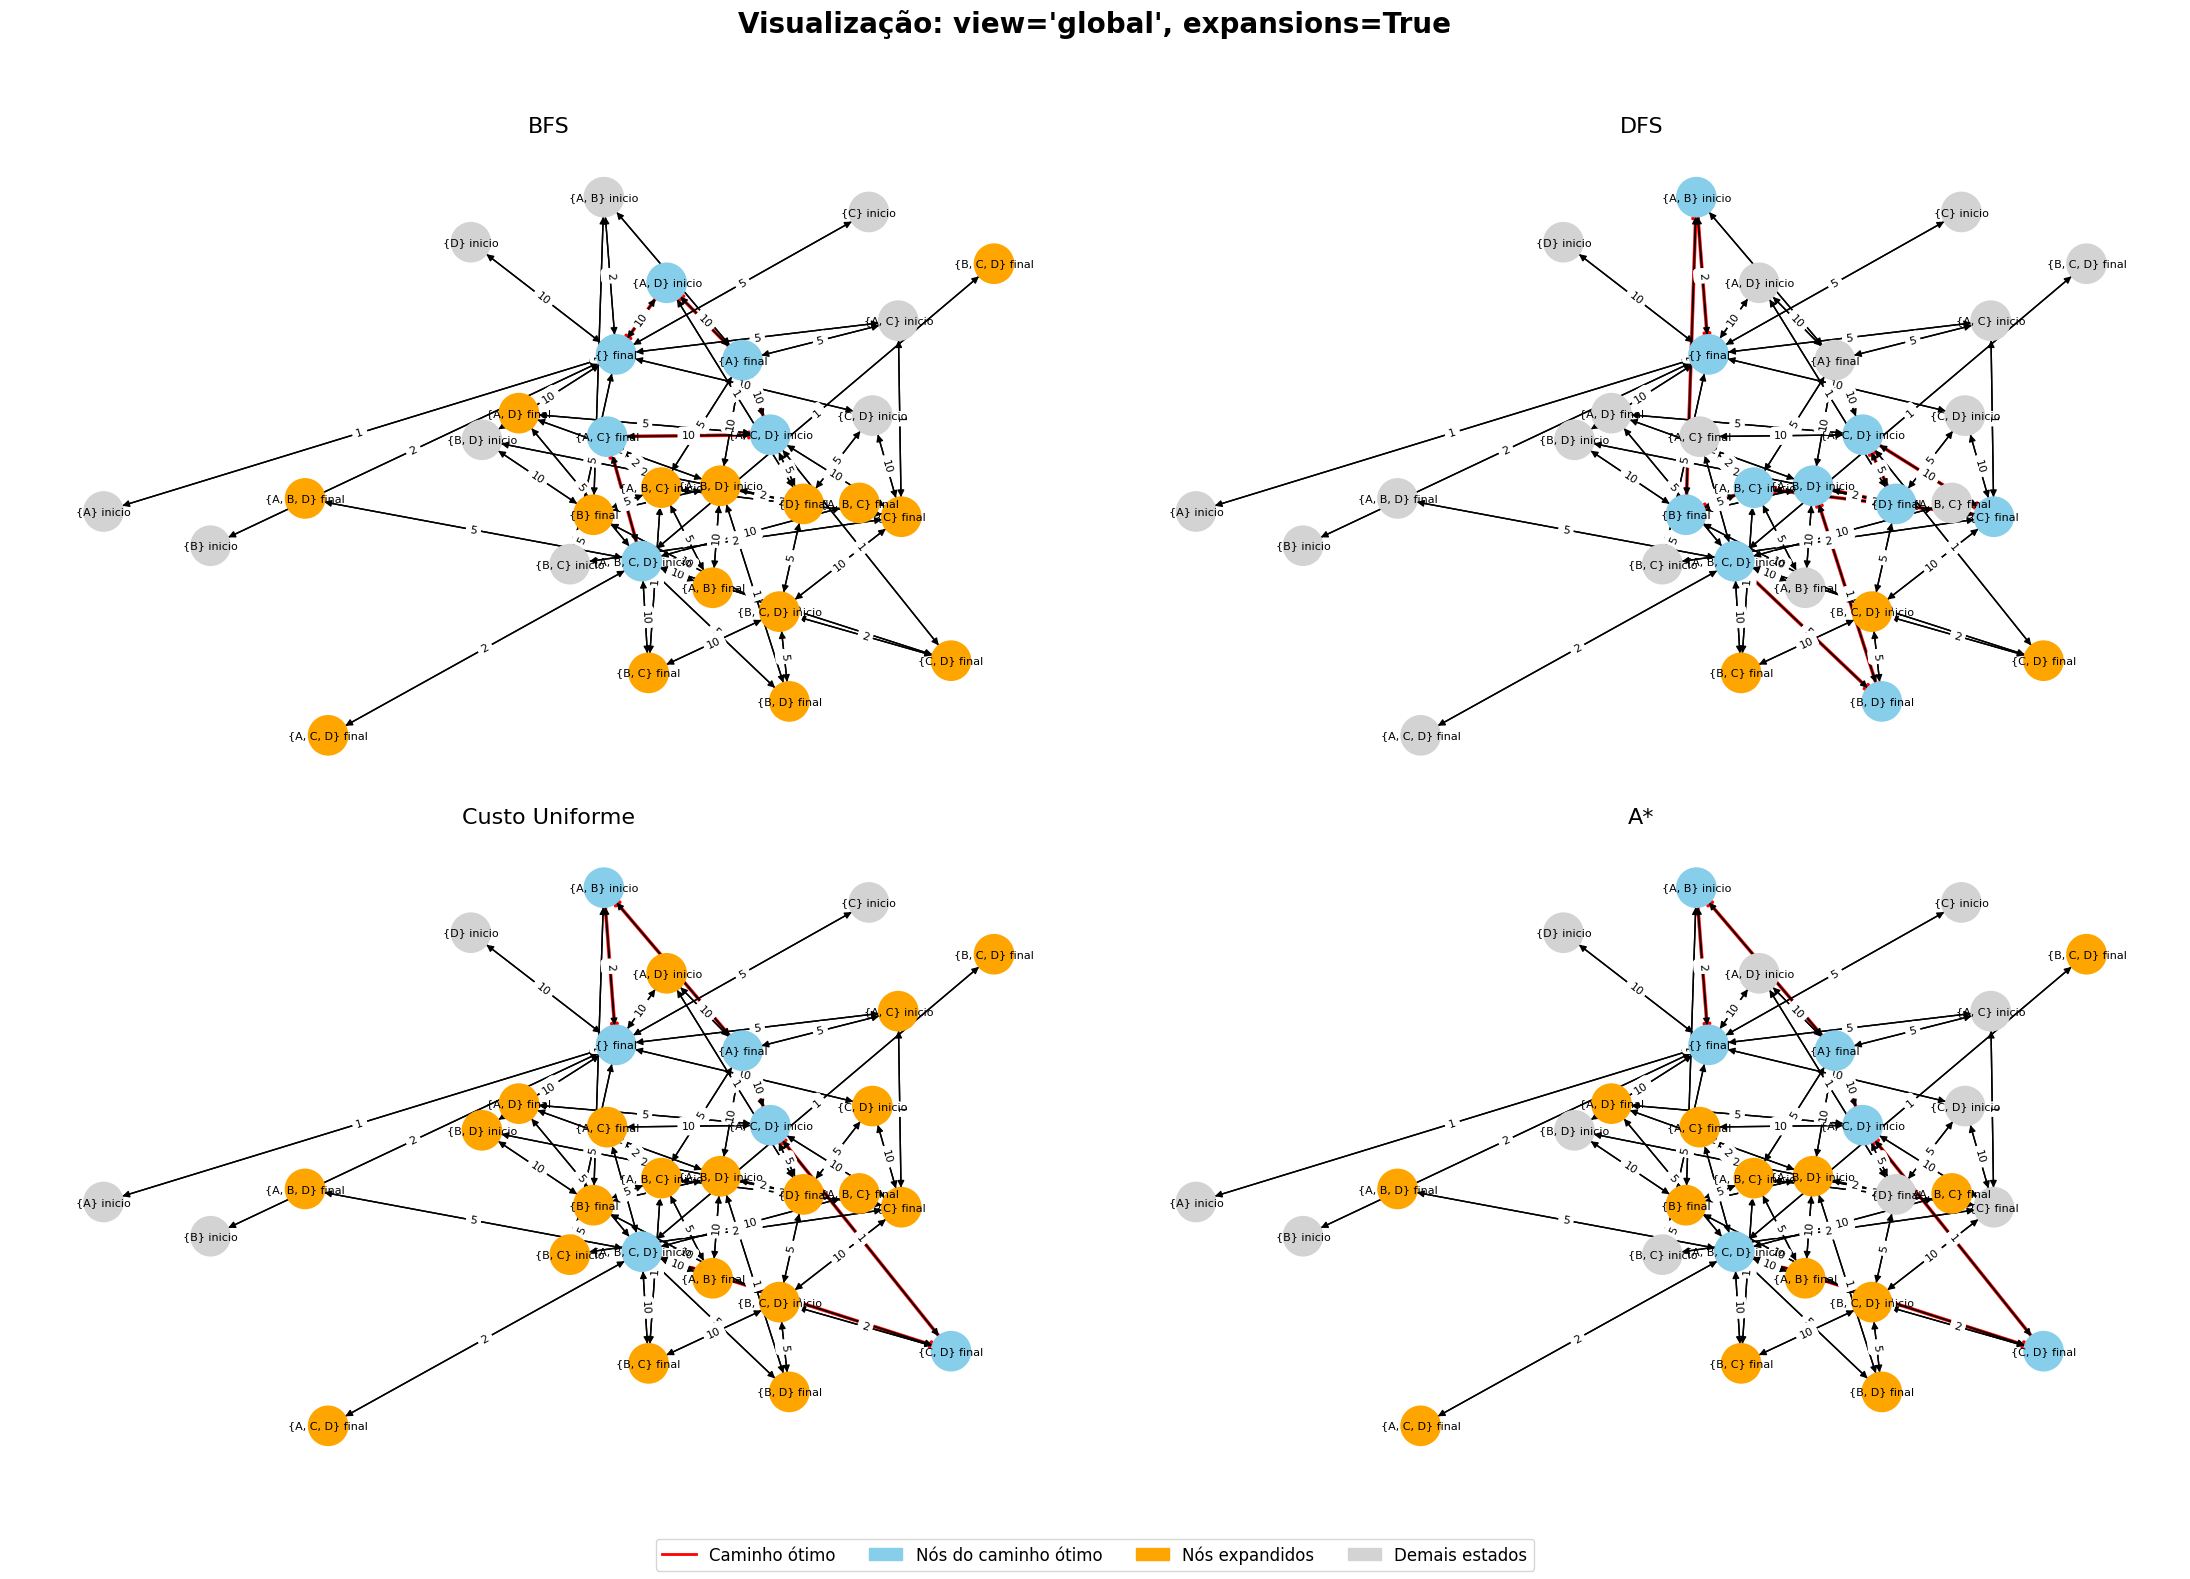

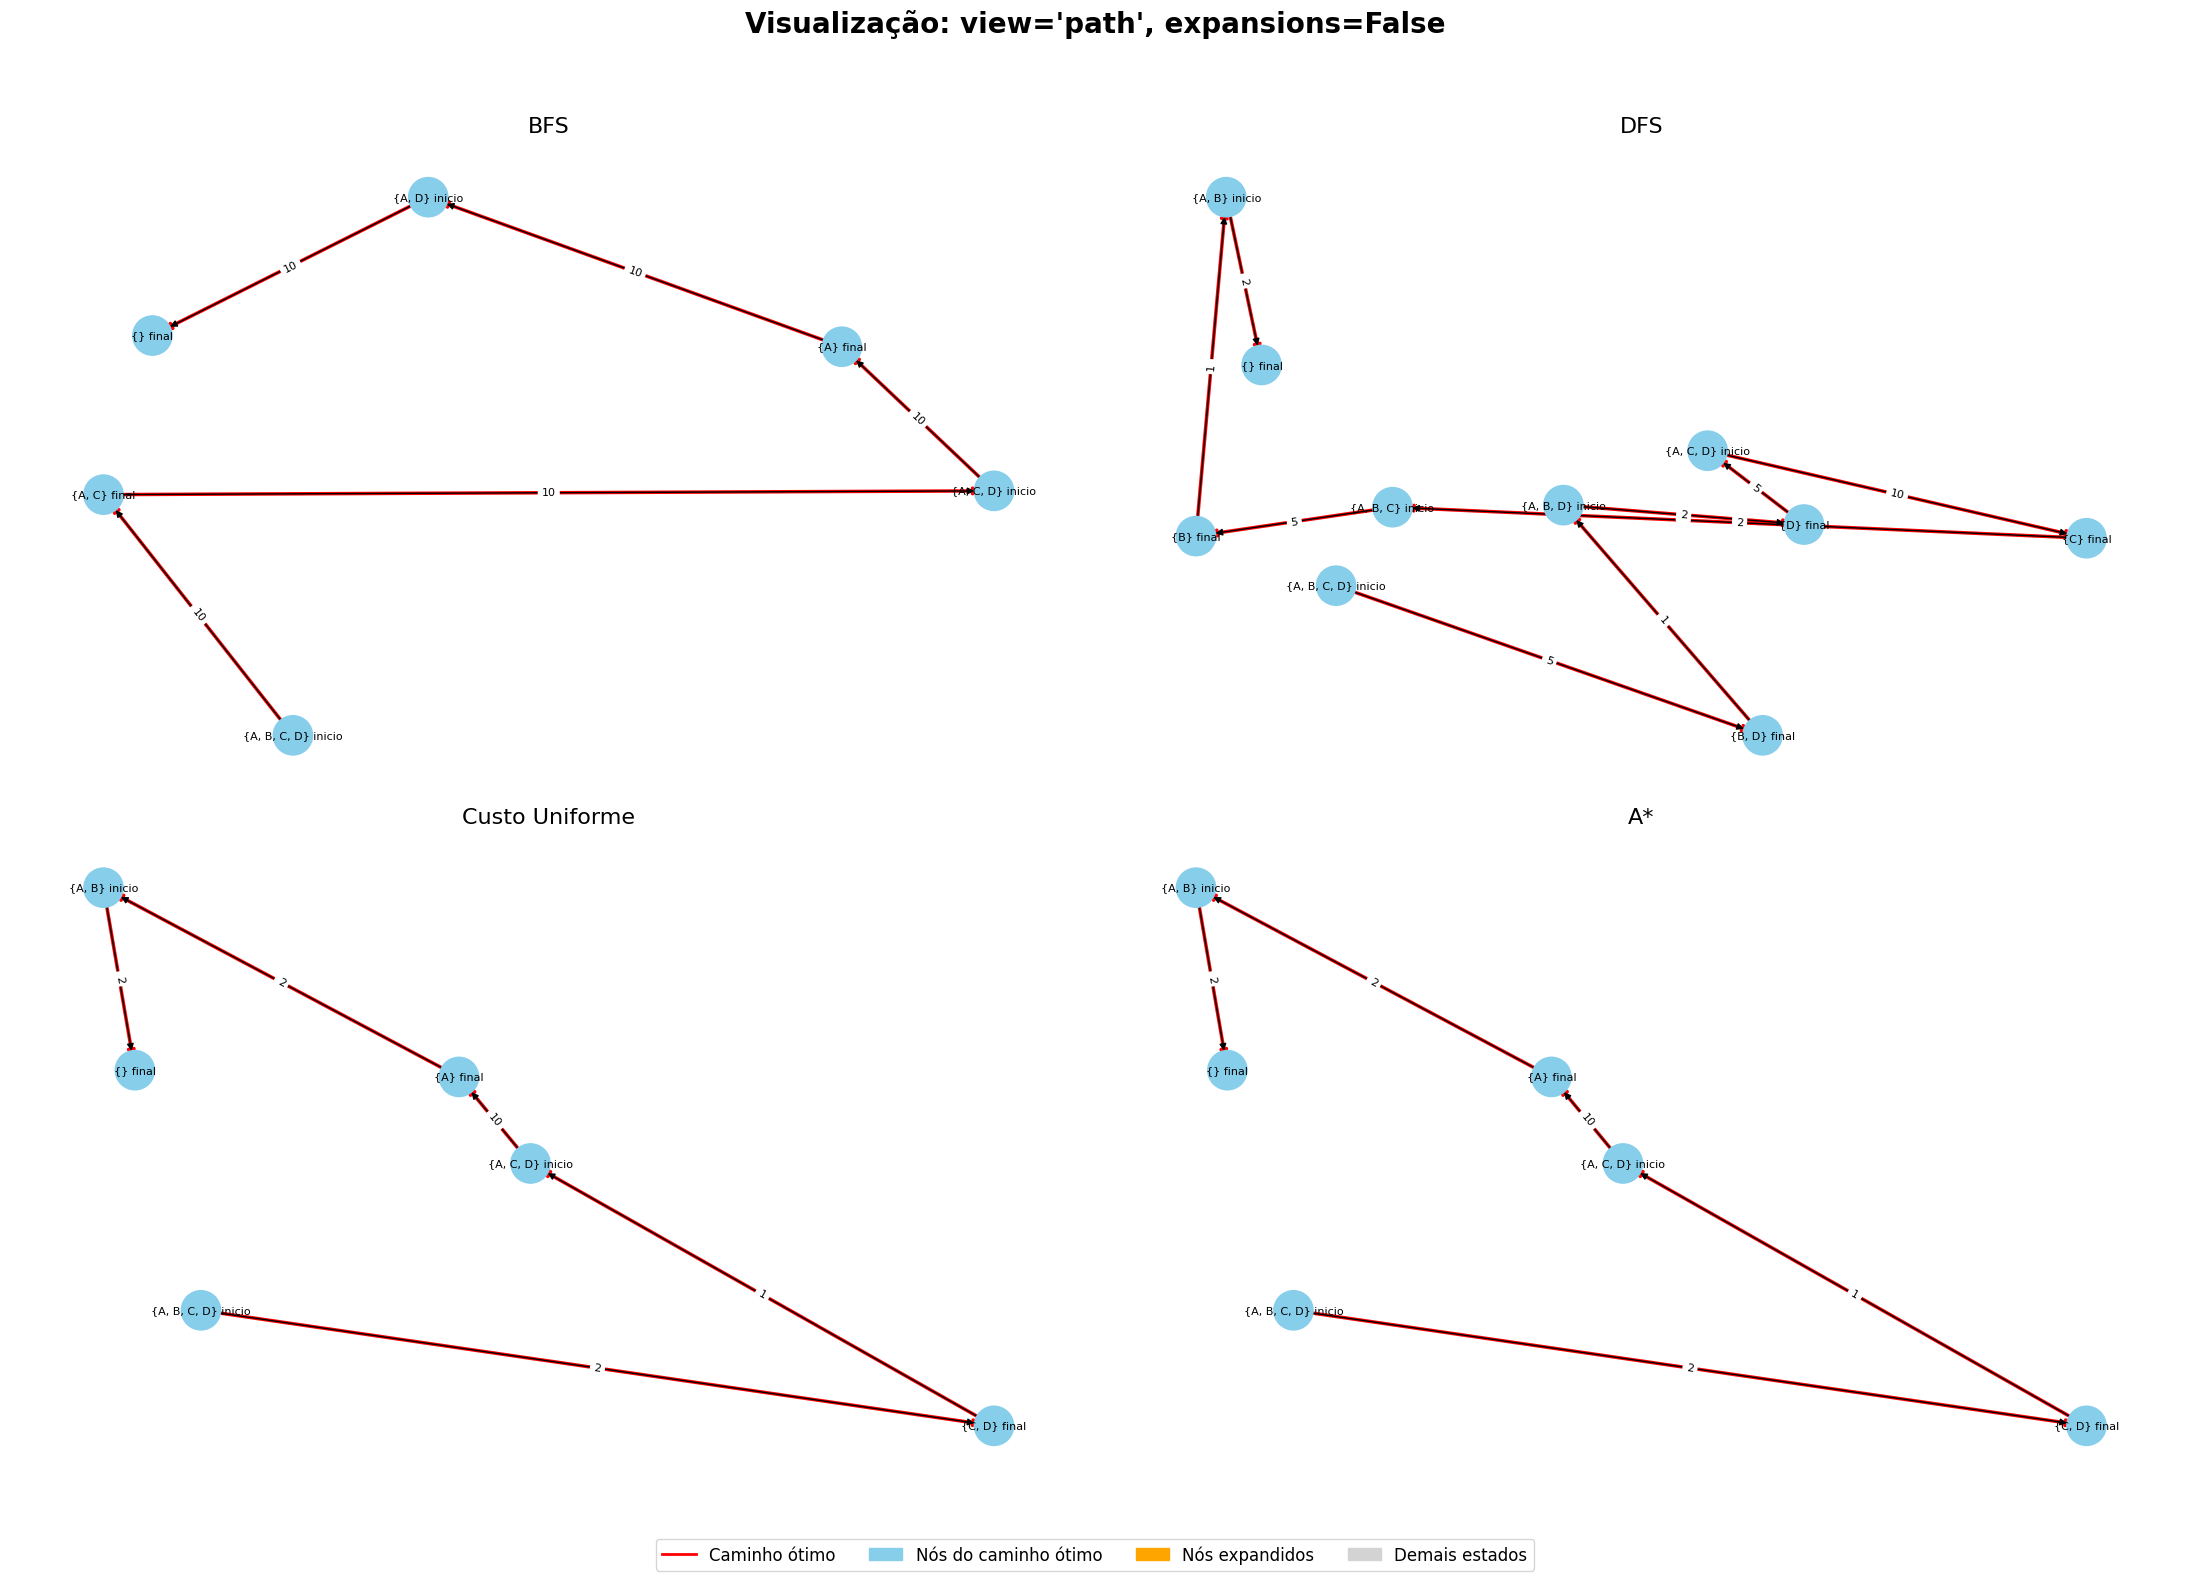

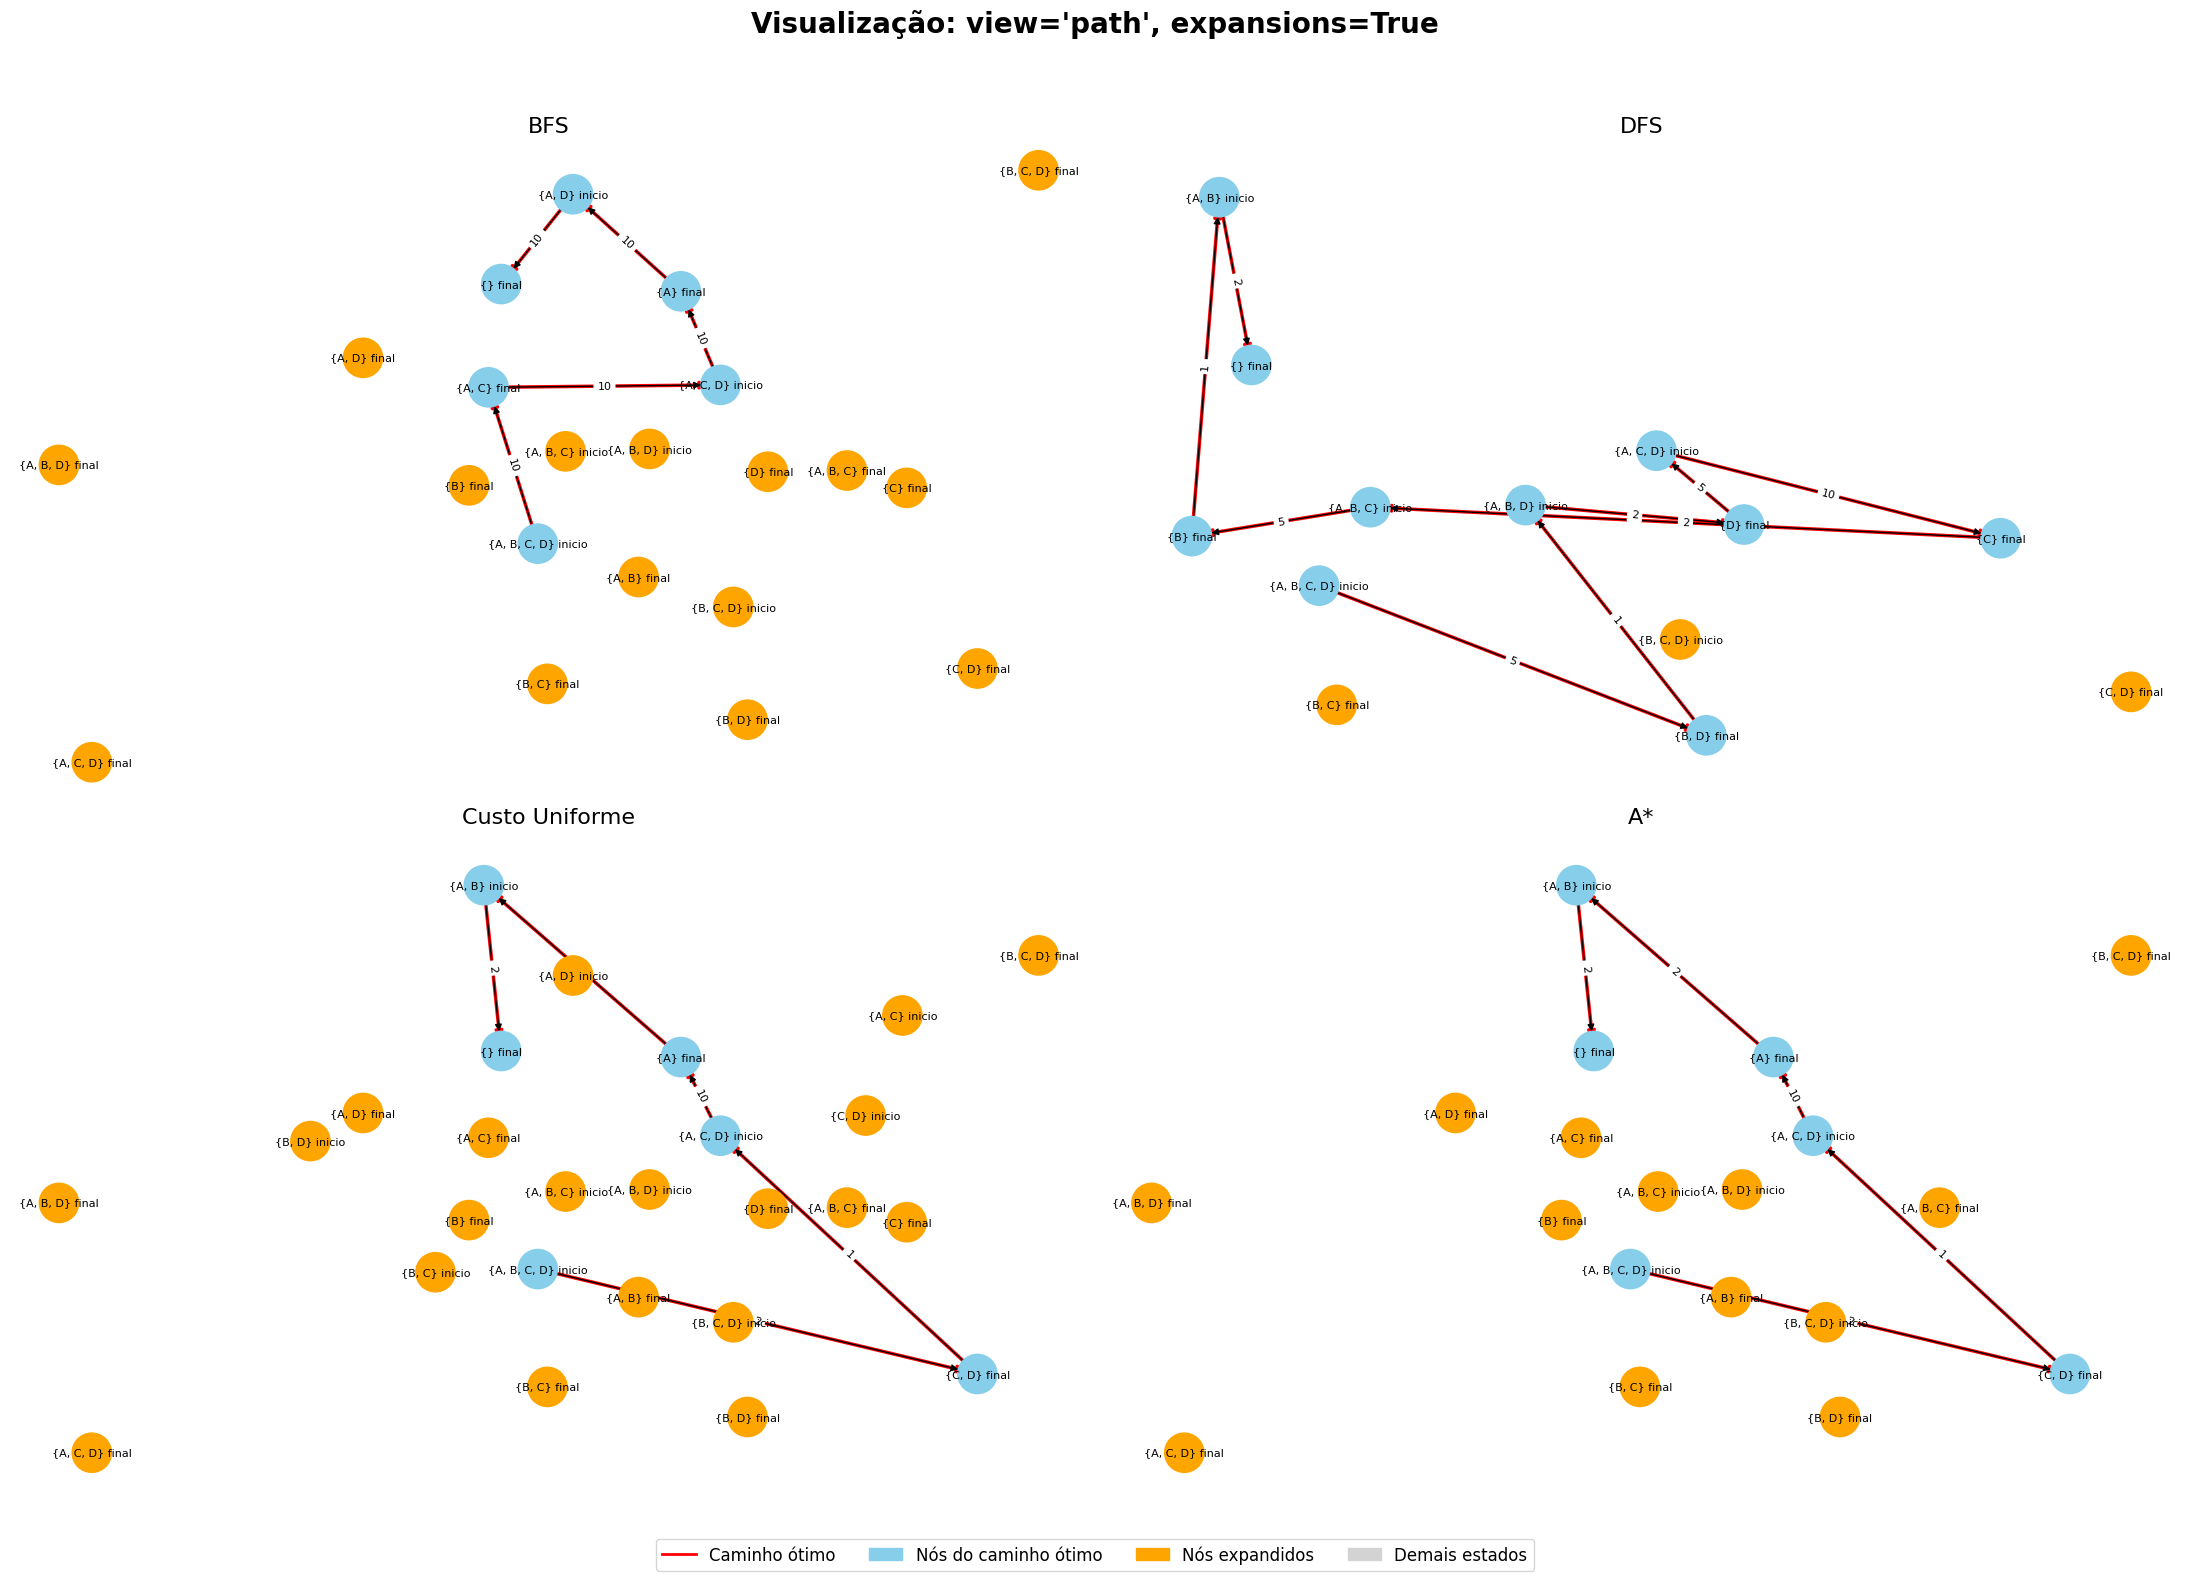

In [5]:
combinacoes = [
    ("global", False),
    ("global", True),
    ("path", False),
    ("path", True)
]

legenda = [
    Line2D([0], [0], color='red', lw=2, label='Caminho ótimo'),
    Patch(color='skyblue', label='Nós do caminho ótimo'),
    Patch(color='orange', label='Nós expandidos'),
    Patch(color='lightgray', label='Demais estados')
]

for view, expansions in combinacoes:
    fig, axes = plt.subplots(2, 2, figsize=(22, 16))
    fig.suptitle(
        f"Visualização: view='{view}', expansions={expansions}",
        fontsize=20,
        fontweight='bold'
    )

    for ax, alg in zip(axes.flat, algoritmos):
        alg.plot(view=view, expansions=expansions, ax=ax)
        ax.set_title(alg.nome, fontsize=16)

    fig.legend(handles=legenda, loc='lower center', ncol=4, fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()